In [19]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
from statsmodels.stats.proportion import proportions_ztest

pd.set_option('display.max_columns', None)


sns.set_style('ticks', rc={"axes.facecolor": (0, 0, 0, 0)})
sns.set_context('talk')

from matplotlib import rcParams
rcParams['font.family'] = 'sans-serif'
rcParams['font.sans-serif'] = ['Arial']
import matplotlib.ticker as ticker

In [27]:
def process_core_tab(file_path):
    df = pd.read_csv(file_path, sep="\t")
    mutation_spectra = []
    for _, row in df.iterrows():
        ref = row["REF"]
        # Ignore first 3 columns (CHR, POS, REF)
        for sample in df.columns[3:]:
            alt = row[sample]
            if ref != alt:
                mutation_spectra.append(f"{ref}>{alt}")
    return mutation_spectra


def collect_mutation_data(input_dir, selected_samples=None):
    mutation_data = []
    subdirs = [d for d in os.listdir(input_dir) if os.path.isdir(os.path.join(input_dir, d))]

    # If user specifies subset of samples
    if selected_samples:
        subdirs = [d for d in selected_samples if d in subdirs]

    mutation_groups = {
        "A>T / T>A": ["A>T", "T>A"],
        "A>C / T>G": ["A>C", "T>G"],
        "A>G / T>C": ["A>G", "T>C"],
        "G>T / C>A": ["G>T", "C>A"],
        "G>C / C>G": ["G>C", "C>G"],
        "C>T / G>A": ["C>T", "G>A"]
    }

    # Track how many times each shortened name appears
    name_counts = {}

    for subdir in subdirs:
        # shorten name by removing everything after last underscore
        base_name = subdir.rsplit("_", 1)[0] if "_" in subdir else subdir

        # add numeric suffix if duplicate
        count = name_counts.get(base_name, 0) + 1
        name_counts[base_name] = count
        short_name = f"{base_name}_{count}" if count > 1 else base_name

        core_tab_path = os.path.join(input_dir, subdir, "core.tab")
        if os.path.exists(core_tab_path):
            mutations = process_core_tab(core_tab_path)
            mutation_counts = dict(Counter(mutations))
            total_mutations = sum(mutation_counts.values()) or 1

            for group, members in mutation_groups.items():
                count_group = sum(mutation_counts.get(m, 0) for m in members)
                mutation_data.append([short_name, group, count_group / total_mutations])

    return pd.DataFrame(mutation_data, columns=["Patient", "Mutation Group", "Frequency"])


def plot_mutation_spectra(mutation_df, output_file="mutation_spectra_plot.png"):
    if mutation_df.empty:
        print("No mutation data to plot.")
        return

    plt.figure(figsize=(7, 4))
    sns.set_theme(style="whitegrid")

    pale_palette = ["#E5C494", "#A2B9D0", "#A2D0A5",
                    "#C6A2D0", "#D0C6A2", "#A2D0D0"]

    # Ensure Patient ordering
    mutation_df["Patient"] = pd.Categorical(
        mutation_df["Patient"],
        categories=mutation_df["Patient"].unique(),
        ordered=True
    )

    ax = sns.barplot(
        data=mutation_df,
        x="Patient",
        y="Frequency",
        hue="Mutation Group",
        palette=pale_palette
    )

    plt.ylabel("Proportion of Mutations")
    plt.xlabel("")
    plt.xticks(rotation=0, ha="right")
    plt.ylim(0, 0.5)  # set y-axis limit

    # --- Statistical comparison to reference ---
    patients = mutation_df["Patient"].cat.categories
    reference = patients[0]  # first sample as reference

    reference_df = mutation_df[mutation_df["Patient"] == reference]

    print(f"Comparing all samples to reference: {reference}\n")
    for patient in patients[1:]:
        patient_df = mutation_df[mutation_df["Patient"] == patient]

        print(f"Patient: {patient}")
        for group in mutation_df["Mutation Group"].unique():
            ref_freq = reference_df.loc[reference_df["Mutation Group"] == group, "Frequency"].values[0]
            pat_freq = patient_df.loc[patient_df["Mutation Group"] == group, "Frequency"].values[0]

            # Convert frequencies to counts assuming same total mutations as reference
            ref_count = int(ref_freq * 100)  # scale to 100 for proportions
            pat_count = int(pat_freq * 100)
            counts = np.array([pat_count, ref_count])
            nobs = np.array([100, 100])

            stat, pval = proportions_ztest(counts, nobs)
            print(f"  {group}: ref={ref_freq:.2f}, patient={pat_freq:.2f}, p={pval:.4f}")
        print()

    plt.legend(title="Mutation Spectrum", facecolor="white", bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.savefig(output_file, dpi=300)
    plt.show()


In [17]:
# --- User-defined settings ---
input_dir = "/big-storage/judit/clockrates/data/kpneumoniae/"
output_file = "mutation_spectra_kp.svg"
selected_samples = ["34_366bbcdc7cb3f86fc577dcaf77e017d2", "97_170c089e0dac23643a5afc931f1094ab", "8_103a69895ddee777a49d7528e16c941a", "303_66eb78dba934c4731f8fdad8b13d6596"]

# --- Run analysis ---
mutation_df = collect_mutation_data(input_dir, selected_samples)
mutation_df

,Patient,Mutation Group,Frequency
0,34,A>T / T>A,0.076101
1,34,A>C / T>G,0.121710
2,34,A>G / T>C,0.302841
3,34,G>T / C>A,0.143081
4,34,G>C / C>G,0.061897
5,34,C>T / G>A,0.294371
6,97,A>T / T>A,0.091905
7,97,A>C / T>G,0.122170
8,97,A>G / T>C,0.314859
9,97,G>T / C>A,0.094421


Comparing all samples to reference: 34

Patient: 97
  A>T / T>A: ref=0.08, patient=0.09, p=0.6022
  A>C / T>G: ref=0.12, patient=0.12, p=1.0000
  A>G / T>C: ref=0.30, patient=0.31, p=0.8779
  G>T / C>A: ref=0.14, patient=0.09, p=0.2678
  G>C / C>G: ref=0.06, patient=0.07, p=1.0000
  C>T / G>A: ref=0.29, patient=0.31, p=0.7576

Patient: 8
  A>T / T>A: ref=0.08, patient=0.09, p=0.7883
  A>C / T>G: ref=0.12, patient=0.13, p=1.0000
  A>G / T>C: ref=0.30, patient=0.29, p=0.8768
  G>T / C>A: ref=0.14, patient=0.11, p=0.3841
  G>C / C>G: ref=0.06, patient=0.08, p=0.5794
  C>T / G>A: ref=0.29, patient=0.30, p=0.8768

Patient: 303
  A>T / T>A: ref=0.08, patient=0.08, p=0.7883
  A>C / T>G: ref=0.12, patient=0.13, p=1.0000
  A>G / T>C: ref=0.30, patient=0.29, p=0.8768
  G>T / C>A: ref=0.14, patient=0.12, p=0.6741
  G>C / C>G: ref=0.06, patient=0.06, p=1.0000
  C>T / G>A: ref=0.29, patient=0.31, p=0.7576



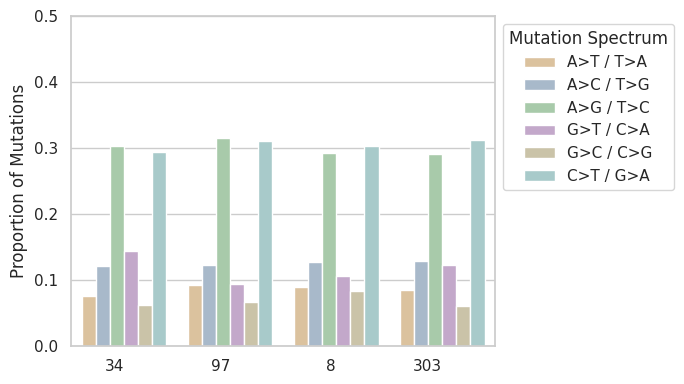

In [21]:
plot_mutation_spectra(mutation_df, output_file)

In [23]:
# --- User-defined settings ---
input_dir = "/big-storage/judit/clockrates/data/ecoli/"
output_file = "mutation_spectra_ec.svg"
selected_samples = ["67_412c0cced8f96f547c374efbf64d01ce", "94_b5bdb54296aa12540bfb66d8f4d53a24"]

# --- Run analysis ---
mutation_df = collect_mutation_data(input_dir, selected_samples)
mutation_df

,Patient,Mutation Group,Frequency
0,67,A>T / T>A,0.073328
1,67,A>C / T>G,0.078520
2,67,A>G / T>C,0.351797
3,67,G>T / C>A,0.079221
4,67,G>C / C>G,0.050087
5,67,C>T / G>A,0.367047
6,94,A>T / T>A,0.077505
7,94,A>C / T>G,0.076770
8,94,A>G / T>C,0.352634
9,94,G>T / C>A,0.072133


Comparing all samples to reference: 67

Patient: 94
  A>T / T>A: ref=0.07, patient=0.08, p=1.0000
  A>C / T>G: ref=0.08, patient=0.08, p=1.0000
  A>G / T>C: ref=0.35, patient=0.35, p=1.0000
  G>T / C>A: ref=0.08, patient=0.07, p=1.0000
  G>C / C>G: ref=0.05, patient=0.05, p=1.0000
  C>T / G>A: ref=0.37, patient=0.37, p=1.0000



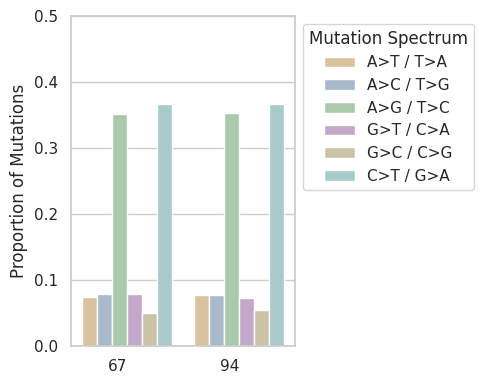

In [26]:
plot_mutation_spectra(mutation_df, output_file)

In [28]:
# --- User-defined settings ---
input_dir = "/big-storage/judit/clockrates/data/paeruginosa/"
output_file = "mutation_spectra_pa.svg"
selected_samples = ["125_968cea793b64f872a9d813a7221b4d13", "3_d53ebeed867721d29bb3f0032db17eae", "33_dbf477aeacef9c3e28261443163caa24", "4_ab6d45059415c33f7ff3e26a496f21ab"]

# --- Run analysis ---
mutation_df = collect_mutation_data(input_dir, selected_samples)
mutation_df

,Patient,Mutation Group,Frequency
0,125,A>T / T>A,0.067542
1,125,A>C / T>G,0.118527
2,125,A>G / T>C,0.359261
3,125,G>T / C>A,0.099940
4,125,G>C / C>G,0.099061
5,125,C>T / G>A,0.255670
6,3,A>T / T>A,0.032212
7,3,A>C / T>G,0.089388
8,3,A>G / T>C,0.387348
9,3,G>T / C>A,0.092520


Comparing all samples to reference: 125

Patient: 3
  A>T / T>A: ref=0.07, patient=0.03, p=0.3062
  A>C / T>G: ref=0.12, patient=0.09, p=0.4694
  A>G / T>C: ref=0.36, patient=0.39, p=0.6595
  G>T / C>A: ref=0.10, patient=0.09, p=1.0000
  G>C / C>G: ref=0.10, patient=0.14, p=0.3660
  C>T / G>A: ref=0.26, patient=0.26, p=1.0000

Patient: 33
  A>T / T>A: ref=0.07, patient=0.05, p=0.5164
  A>C / T>G: ref=0.12, patient=0.09, p=0.4694
  A>G / T>C: ref=0.36, patient=0.30, p=0.3631
  G>T / C>A: ref=0.10, patient=0.09, p=1.0000
  G>C / C>G: ref=0.10, patient=0.17, p=0.1345
  C>T / G>A: ref=0.26, patient=0.31, p=0.4285

Patient: 4
  A>T / T>A: ref=0.07, patient=0.04, p=0.3062
  A>C / T>G: ref=0.12, patient=0.08, p=0.4694
  A>G / T>C: ref=0.36, patient=0.34, p=0.7653
  G>T / C>A: ref=0.10, patient=0.09, p=0.7998
  G>C / C>G: ref=0.10, patient=0.15, p=0.1917
  C>T / G>A: ref=0.26, patient=0.30, p=0.5241



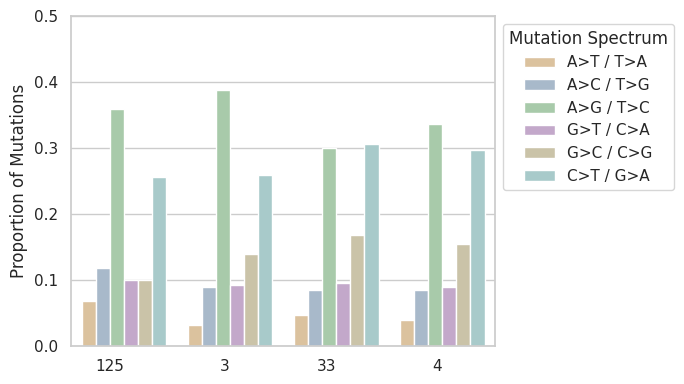

In [29]:
plot_mutation_spectra(mutation_df, output_file)

In [30]:
pwd

'/big-storage/judit/clockrates/workflow/jupyternotebooks'